# Варіант 2
1. Виконати токенізацію тексту за допомогою spaCy.
2. Визначити частини мови для кожного слова в тексті.
3. Створити векторні представлення речень.
4. Обчислити косинусну подібність між двома реченнями.
5. Використовуючи FastText, визначити, яке слово найменш схоже на інші у списку

Макса дуже ганяли по теорії а потім завернули, тому тут її буде більше

## 1. Виконати токенізацію тексту за допомогою spaCy.

Токенізація – процес розбиття тексту на менші частини, що називаються 
токенами. Токени можуть бути словами, фразами, або навіть окремими 
символами. Це є першочерговий крок в обробці текстових даних, оскільки він 
дозволяє працювати з текстом на рівні, який може обробляти комп'ютер. 


Приклади методів токенізації: лексемний аналіз (на основі пробілів та знаків 
пунктуації), словникова токенізація (на основі попередньо визначеного 
словника) та н-грам токенізація (групування токенів у послідовності)

Оскільки комп'ютери оперують числовими даними, кожен токен 
перетворюється на числове представлення. Це може бути як простий спосіб –
присвоєння кожному токену унікального ідентифікатора, так і складний –
створення багатовимірних векторів, які відображають значення і контекст 
токена.


In [1]:
# перш ніж юзати модельки, треба їх качнути, стаковерфлов каже робити так
!python -m spacy download en
# качає одразу і малу і велику моделі, але воно видає помилки, 
# тому можна і просто
# !python -m spacy download en-core-web-sm==3.8.0

⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.9 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/12.8 MB 1.9 MB/s eta 0:00:07
     ---- ----------------------------------- 1.3/12.8 MB 1.7 MB/s eta 0:00:07
     ---- ----------------------------------- 1.6/12.8 MB 1.7 MB/s eta 0:00:07
     ----- ---------------------------------- 1.8/12.8 MB 1.7 MB/s eta 0:00:07
     ------- -------------------------------- 2.4/12.8 MB 1.6 MB/s eta 0:00:07
     -------- ------------------------------- 2.6/12.8 MB 1.6 MB/s eta 0:00:07
     --------- ------------------------------ 2.9/12.8 MB 1.7 MB/s eta 0:00:06
     ---------- ----------------------------- 3.4/12.8 MB 1.7 MB/s eta 0:00:06
     ----------- ----


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# код з методички
import spacy
nlp = spacy.load("en_core_web_sm")
text = "Natural language processing enables machines to understand human language."
doc = nlp(text)
tokens = [token.text for token in doc]
print("Токенізований текст:", tokens)

Токенізований текст: ['Natural', 'language', 'processing', 'enables', 'machines', 'to', 'understand', 'human', 'language', '.']


In [3]:
for token in doc:
  print(token)

Natural
language
processing
enables
machines
to
understand
human
language
.


на оф. сайті spaCy є українська модель: https://spacy.io/models/uk

In [17]:
# - мала модель 14мб
#!python -m spacy download uk_core_news_sm
# - середня 65Мб 
!python -m spacy download uk_core_news_md 
# - велика 220Мб
#!python -m spacy download uk_core_news_lg

# беремо середню, бо середня... середня

     ---------------------------------------- 0.0/69.1 MB ? eta -:--:--
     ---------------------------------------- 0.3/69.1 MB ? eta -:--:--
     ---------------------------------------- 0.5/69.1 MB 1.5 MB/s eta 0:00:45
      --------------------------------------- 1.0/69.1 MB 1.7 MB/s eta 0:00:40
      --------------------------------------- 1.3/69.1 MB 1.7 MB/s eta 0:00:41
      --------------------------------------- 1.6/69.1 MB 1.7 MB/s eta 0:00:41
     - -------------------------------------- 1.8/69.1 MB 1.7 MB/s eta 0:00:41
     - -------------------------------------- 2.1/69.1 MB 1.6 MB/s eta 0:00:42
     - -------------------------------------- 2.6/69.1 MB 1.6 MB/s eta 0:00:42
     - -------------------------------------- 2.9/69.1 MB 1.6 MB/s eta 0:00:42
     - -------------------------------------- 3.1/69.1 MB 1.6 MB/s eta 0:00:41
     -- ------------------------------------- 3.7/69.1 MB 1.6 MB/s eta 0:00:40
     -- ------------------------------------- 3.9/69.1 MB 1.7 MB/s


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import spacy
from spacy.lang.uk.examples import sentences 

nlp = spacy.load("uk_core_news_sm")
doc = nlp(sentences[0])
print(doc.text)
for token in doc:
    print(token.text)

Ніч на середу буде морозною.
Ніч
на
середу
буде
морозною
.


## 2. Визначити частини мови для кожного слова в тексті.

Крім того, для кращого аналізу тексту використовуються методи 
морфологічного та синтаксичного аналізу. 
Морфологічний аналіз є процесом визначення структури слів, 
включаючи морфеми, що є найменшими значущими одиницями мови. 

Морфологічний аналіз дозволяє розбити слова на корінь, префікси, суфікси та 
інші елементи, що допомагає розуміти зміст і структуру слова. Це важливо для 
мов, де слова можуть мати багато граматичних форм (наприклад, українська 
або англійська).

Синтаксичний аналіз визначає граматичну структуру речень, 
включаючи визначення частин мови (іменники, дієслова, прикметники тощо) 
та відношень між словами. Мета синтаксичного аналізу – побудувати дерево 
залежностей, що представляє структуру речення, що допомагає зрозуміти 
зміст тексту.

In [6]:
sentence = "Ох, як мені подобається навчатись у 'Львівській Політехніці'!"
doc = nlp(sentence)
for token in doc:
    print(token.text, token.pos_, token.dep_)

Ох INTJ discourse
, PUNCT punct
як ADV advmod
мені PRON obj
подобається VERB ROOT
навчатись VERB xcomp
у ADP case
' PUNCT punct
Львівській ADJ amod
Політехніці NOUN obl
' PUNCT punct
! X punct


в нас одна державна мова, тому попросим чат всьо перекласти

In [7]:
pos_translation = {
    "ADJ": "прикметник",
    "ADP": "прийменник",
    "ADV": "прислівник",
    "AUX": "допоміжне дієслово",
    "CONJ": "сполучник",
    "CCONJ": "сполучник (сурядний)",
    "DET": "детермінатив (означник)",
    "INTJ": "вигук",
    "NOUN": "іменник",
    "NUM": "числівник",
    "PART": "частка",
    "PRON": "займенник",
    "PROPN": "власна назва",
    "PUNCT": "розділовий знак",
    "SCONJ": "сполучник (підрядний)",
    "SYM": "символ",
    "VERB": "дієслово",
    "X": "інше",
    "SPACE": "пробіл"
}

In [8]:
dep_translation = {
    "acl": "підрядне означальне речення",
    "advcl": "підрядне обставинне речення",
    "advmod": "обставина",
    "amod": "означення (прикметникове)",
    "appos": "прикладка",
    "aux": "допоміжне дієслово",
    "case": "прийменник або післяйменник",
    "cc": "сполучник",
    "ccomp": "додаткове підрядне речення",
    "compound": "складова частина",
    "conj": "сполучене речення або слово",
    "cop": "зв'язка",
    "csubj": "підмет у підрядному реченні",
    "dep": "незалежна залежність",
    "det": "означник",
    "discourse": "мовний елемент (дискурс)",
    "fixed": "фіксована фраза",
    "flat": "плоска структура (наприклад, ім'я)",
    "goeswith": "продовження слова",
    "iobj": "непрямий додаток",
    "list": "елемент списку",
    "mark": "підрядний сполучник",
    "nmod": "іменникове означення",
    "nsubj": "підмет",
    "nummod": "числівникове означення",
    "obj": "прямий додаток",
    "obl": "обставина",
    "orphan": "сирота (без головного слова)",
    "parataxis": "паралельне речення",
    "punct": "розділовий знак",
    "reparandum": "виправлення",
    "root": "корінь речення",
    "vocative": "кличний відмінок",
    "xcomp": "додаток без підмета"
}


In [9]:
sentence = "Ох, як мені подобається навчатись у 'Львівській Політехніці'!"
doc = nlp(sentence)
doc_token_dict = {}
for token in doc:
    doc_token_dict[token] = [
        pos := pos_translation.get(token.pos_), # part of speech
        dep := dep_translation.get(token.dep_) # syntactic dependencies
    ]
    print("{} | {}, {}".format(token, pos, dep))

Ох | вигук, мовний елемент (дискурс)
, | розділовий знак, розділовий знак
як | прислівник, обставина
мені | займенник, прямий додаток
подобається | дієслово, None
навчатись | дієслово, додаток без підмета
у | прийменник, прийменник або післяйменник
' | розділовий знак, розділовий знак
Львівській | прикметник, означення (прикметникове)
Політехніці | іменник, обставина
' | розділовий знак, розділовий знак
! | інше, розділовий знак


не зле, але тепер прикрасим то всьо

In [10]:
import pandas as pd

pd.DataFrame(doc_token_dict).T.rename({
    0: "Частина Мови",
    1: "Синтаксична залежність",
}, axis=1)

,Частина Мови,Синтаксична залежність
Ох,вигук,мовний елемент (дискурс)
",",розділовий знак,розділовий знак
як,прислівник,обставина
мені,займенник,прямий додаток
подобається,дієслово,None
навчатись,дієслово,додаток без підмета
у,прийменник,прийменник або післяйменник
',розділовий знак,розділовий знак
Львівській,прикметник,означення (прикметникове)
Політехніці,іменник,обставина


і запихнем у функцію на майбутнє

In [11]:
def sentence_analyses(sentence):
    doc = nlp(sentence)
    doc_token_dict = {}
    for token in doc:
        doc_token_dict[token] = [
            pos_translation.get(token.pos_),
            dep_translation.get(token.dep_),
        ]
    return pd.DataFrame(doc_token_dict).T.rename({
        0: "Частина Мови",
        1: "Синтаксична залежність",
    }, axis=1)

In [12]:
sentence_analyses("Еней був парубок моторний, і хлопець хоч куди ...")

,Частина Мови,Синтаксична залежність
Еней,іменник,підмет
був,допоміжне дієслово,зв'язка
парубок,іменник,None
моторний,прикметник,означення (прикметникове)
",",розділовий знак,розділовий знак
і,сполучник (сурядний),сполучник
хлопець,іменник,сполучене речення або слово
хоч,частка,мовний елемент (дискурс)
куди,прислівник,обставина
...,інше,сполучене речення або слово


тут парубок мав би бути додатком (?) але

в цієї конкретно можельки точність на частини мови 98%, тому я б їй на контрольній довірився

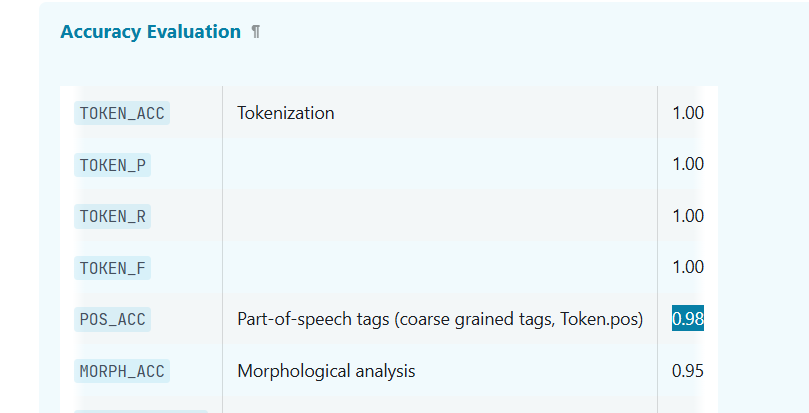

## 3. Створити векторні представлення речень.

Наступним важливим кроком є вбудовування слів (Word Embeddings). 
Це метод представлення слів у багатовимірному числовому просторі, що 
дозволяє зберігати їхню семантику

FastText є покращеною версією Word2Vec 

(Word2Vec навчається за двома підходами: Skip-gram, який передбачає 
ймовірність сусідніх слів на основі центрального слова, та CBOW (Continuous 
Bag of Words), який працює навпаки – передбачає центральне слово за 
контекстом)

, яка використовує 
підсловні вектори, що робить його ефективним для роботи з морфологічно 
багатими мовами.

In [13]:
# код з методички
from gensim.models import FastText
sentences = [
    ["Machine", "learning", "is", "amazing"],
    ["Natural", "language", "processing", "is", "a", "part", "of", "AI"],
    ["Word", "embeddings", "improve", "text", "representation"]
]
model = FastText(
    sentences, 
    vector_size=50, 
    window=5, 
    min_count=1, 
    workers=4
)
print("Вектор для слова 'language':\n", model.wv["language"])

Вектор для слова 'language':
 [-3.8007209e-03  2.7522242e-03  1.4515182e-03 -3.3996981e-03
 -4.5403601e-03  3.0829683e-03 -1.0596433e-05 -5.0393131e-04
 -2.5027960e-03 -1.2855418e-03  2.4373264e-03 -4.3361931e-04
  1.1254573e-03 -9.9513956e-05  3.8513336e-03  1.4718579e-03
  8.2464365e-04  4.9788682e-03 -5.1786657e-05 -1.8232825e-03
 -2.3850668e-04 -2.0606925e-04 -1.1395437e-03  4.2057461e-03
 -5.0706643e-04  2.0952413e-05 -5.9934002e-03 -2.3238081e-03
  3.5444403e-03 -5.0723902e-04  4.7397758e-03  3.5603115e-04
  9.8965445e-04 -2.8662357e-04 -1.9283473e-03 -2.4503851e-03
  9.5623033e-04  1.1507415e-03 -3.4047156e-03  2.8564809e-03
 -7.0216390e-04  4.1157901e-03 -5.7201617e-04  1.3307105e-03
  2.4655284e-03 -3.5718290e-04  2.0023594e-03 -2.2395684e-03
 -6.0036808e-04  8.1513409e-04]


## 4. Обчислити косинусну подібність між двома реченнями.

In [14]:
import numpy as np

def cos_similarity(a, b):
    """
        Обчислити косинусну подібність між двома заданими словами.
    """
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [15]:
a, b = model.wv['language'], model.wv['AI']
cos_similarity(a, b)

-0.04432176

тобто поняття слів для "мова" і "ШІ" серед тих речень шо ми дали перпендикулярні - абсолютно не подібні

і тут виникає прікол: "серед тих шо, ми дали", а якшо не серед тих шо ми дали

скачаєм готову модельку

*ми вже качали модельку, але вона не була fasttext-івська, а по лабі треба саме таку

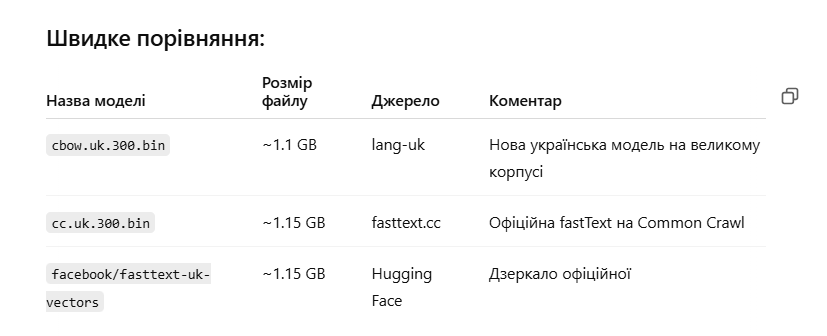

In [ ]:
# https://fasttext.cc/docs/en/crawl-vectors.html # - тут тільки 4 Гб

import fasttext.util
ft_model = fasttext.load_model('cc.uk.300.bin')

We distribute pre-trained word vectors for 157 languages, trained on Common Crawl and Wikipedia using fastText. These models were trained using CBOW with position-weights, in dimension 300, with character n-grams of length 5, a window of size 5 and 10 negatives. We also distribute three new word analogy datasets, for French, Hindi and Polish.

In [26]:
ft_model.get_word_vector('привіт')

array([ 8.52670893e-02,  1.89392027e-02,  6.51533008e-02,  2.25476865e-02,
       -7.11261332e-02,  4.80254134e-03,  2.89529725e-03,  9.54323728e-03,
       -4.82791960e-02, -5.81631735e-02, -4.04151483e-03, -7.72011429e-02,
        6.68871391e-04, -5.91974929e-02,  2.78578047e-02,  1.56495057e-03,
        3.08612585e-02,  2.16798689e-02,  2.58489009e-02, -3.96087319e-02,
        1.18462108e-01, -1.08251646e-01, -3.22717130e-02, -7.12343976e-02,
       -3.62441614e-02, -5.52746318e-02, -2.33362988e-02, -5.75235561e-02,
        8.83644726e-03,  1.09139387e-03, -5.30676655e-02, -9.34428815e-03,
       -2.54473984e-02,  6.14181190e-05, -4.84927297e-02,  4.09286991e-02,
        3.40599902e-02,  8.03436190e-02,  8.61610696e-02, -4.82525602e-02,
       -3.55555713e-02,  6.78462908e-02,  8.06991104e-03,  7.75121450e-02,
        1.64952350e-03, -3.74583863e-02, -1.64084192e-02, -1.90852862e-02,
       -2.41209175e-02,  7.29504749e-02,  2.85144635e-02, -3.89630757e-02,
        1.45275434e-02,  

## 5. Використовуючи FastText, визначити, яке слово найменш схоже на інші у списку

### слово до слова (1 до 1)

In [46]:
word_1, word_2 = "Книжка", "Знання"
a, b = ft_model.get_word_vector(word_1), ft_model.get_word_vector(word_2)
cos_similarity(a, b)

0.2983877

In [48]:
word_1, word_2 = "Сука", "Блядь"
a, b = ft_model.get_word_vector(word_1), ft_model.get_word_vector(word_2)
cos_similarity(a, b)

0.37121877

о рідна мово, "...кто тібя відумал" (с) Майк Йогансен

### слово до багатьох (1 до 9999)

In [49]:
word, words = "Книжка", ["Біблія", "Слово", "Кобзар", "Буквар"]
a = ft_model.get_word_vector(word)
for w in words:
    b = ft_model.get_word_vector(w)
    sim = cos_similarity(a, b)
    print("{} - {} :: {}".format(word, w, sim))

Книжка - Біблія :: 0.4130309820175171
Книжка - Слово :: 0.279306560754776
Книжка - Кобзар :: 0.28258493542671204
Книжка - Буквар :: 0.3677937686443329


In [55]:
w_dict = {}
for w in words:
    b = ft_model.get_word_vector(w)
    sim = cos_similarity(a, b)
    w_dict[w] = sim
word, w_dict

('Книжка',
 {'Біблія': 0.41303098,
  'Слово': 0.27930656,
  'Кобзар': 0.28258494,
  'Буквар': 0.36779377})

In [70]:
from math import inf

min_value = inf
min_key = None
for key, value in w_dict.items():
    if value < min_value:
        min_key, min_value = key, value
min_key, min_value

('Слово', 0.27930656)

In [72]:
def find_similar(word, words):
    a = ft_model.get_word_vector(word)
    w_dict = {}
    for w in words:
        b = ft_model.get_word_vector(w)
        sim = cos_similarity(a, b)
        w_dict[w] = sim
    return w_dict

In [75]:
w_dict = find_similar("Книжка", ["Біблія", "Слово", "Кобзар", "Буквар"])
w_dict

{'Біблія': 0.41303098,
 'Слово': 0.27930656,
 'Кобзар': 0.28258494,
 'Буквар': 0.36779377}

In [110]:
def least_similar(w_dict):
    min_value = 2.0
    min_key = None
    for key, value in w_dict.items():
        if value < min_value:
            min_key, min_value = key, value
    return min_key, min_value
def most_similar(w_dict):
    max_value = -2.0
    max_key = None
    for key, value in w_dict.items():
        if value > max_value:
            max_key, max_value = key, value
    return max_key, max_value

In [77]:
least_similar(w_dict)

('Слово', 0.27930656)

якшо замість нашого списку взяти якусь книжку, то її перше треба буде токенізувати

We used the Stanford word segmenter for Chinese, Mecab for Japanese and UETsegmenter for Vietnamese. For languages using the Latin, Cyrillic, Hebrew or Greek scripts, we used the tokenizer from the Europarl preprocessing tools. For the remaining languages, we used the ICU tokenizer.

тобто шоб токенізувати текст для нашої ft_model треба брати Moses Tokenizer, який юзали в Europarl

In [93]:
!pip install sacremoses

   ---------------------------------------- 0.0/897.5 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/897.5 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/897.5 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 897.5/897.5 kB 1.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
from sacremoses import MosesTokenizer

tokenizer = MosesTokenizer(lang='uk') 

In [96]:
sentence = "Тарас Шевченко народився 9 березня у селі Шевченківське, Луцької області"
tokens = tokenizer.tokenize(sentence)
tokens

['Тарас',
 'Шевченко',
 'народився',
 '9',
 'березня',
 'у',
 'селі',
 'Шевченківське',
 ',',
 'Луцької',
 'області']

In [98]:
w_dict = find_similar("Кобзар", tokens)
w_dict

{'Тарас': 0.4692099,
 'Шевченко': 0.64999485,
 'народився': 0.17263757,
 '9': -0.004827498,
 'березня': 0.14676262,
 'у': 0.013107822,
 'селі': 0.23497523,
 'Шевченківське': 0.38559204,
 ',': -0.011549544,
 'Луцької': 0.10040686,
 'області': 0.12228037}

In [99]:
least_similar(w_dict)

(',', -0.011549544)

тепер можна взяти якийсь величезний текст, токенізувати і знайти найменш подібні слова

In [105]:
with open('shkliar-vasyl-mykolayovych-zalyshenets-chornyy-voron10350.txt', 'r', encoding='cp1251') as f:
    text = f.read()
tokens = tokenizer.tokenize(text)

In [111]:
w_dict = find_similar("Кобзар", tokens)
least_similar(w_dict)
most_similar(w_dict)

('Кобзаря', 0.6929741)

поміняєм код, шоб було щручніше, тепер - списки а не дикти

In [118]:
def find_similar_list(word, words):
    words = set(words)
    a = ft_model.get_word_vector(word)
    w_list = []
    for w in words:
        b = ft_model.get_word_vector(w)
        sim = cos_similarity(a, b)
        w_list.append((w, sim))
    return w_list

In [121]:
w_list = find_similar_list("Кобзар", tokens)
sorted(w_list, key=lambda x: x[1], reverse=True)[:10]

[('Кобзаря', 0.6929741),
 ('Шевченка', 0.55310106),
 ('Тараса', 0.5181979),
 ('Заповіт', 0.488944),
 ('поет', 0.4567602),
 ('Куліш', 0.45640898),
 ('Шевченки', 0.44885185),
 ('Козак', 0.44265145),
 ('козарлюгою', 0.44103682),
 ('народ-то', 0.43816593)]

In [132]:
def similar_list_ordered(word, words, k, reverse):
    w_list = find_similar_list(word, tokens)
    return sorted(w_list, key=lambda x: x[1], reverse=reverse)[:k]

In [133]:
similar_list_ordered("Секс", tokens, 10, True) # True - для найбільш схожих, False - для найменш схожих

[('Сексот', 0.5417044),
 ('знайомства', 0.39360127),
 ('Хвойда', 0.3758783),
 ('цілуватися', 0.34736425),
 ('сексотка', 0.34341767),
 ('Зрада', 0.3432777),
 ('Дурне', 0.3378982),
 ('ліжку', 0.33524543),
 ('цицьки', 0.33265162),
 ('кохання', 0.3325798)]

In [134]:
similar_list_ordered("Секс", tokens, 20, False)

[('&#91;', -0.18622543),
 ('Чопи', -0.15493889),
 ('чотою', -0.12759952),
 ('ночов', -0.11461235),
 ('Ярку', -0.11305866),
 ('од', -0.10695273),
 ('Нач', -0.103314035),
 ('чопи', -0.102805376),
 ('паличку', -0.102699965),
 ('сюд', -0.09928285),
 ('глею', -0.09664673),
 ('хистом', -0.09335472),
 ('чимдуж', -0.092410155),
 ('тини', -0.09217989),
 ('шкутильгав', -0.09192336),
 ('сеї', -0.091481686),
 ('сягнула', -0.09092879),
 ('цоб', -0.08957844),
 ('тиньк', -0.08903436),
 ('очолюю', -0.0887766)]

тепер ше оце в функцію запихнемо

In [138]:
def find_similar_in_book(word, book_src, k, reverse):
    with open(book_src, 'r', encoding='cp1251') as f:
        text = f.read()
    tokens = set(tokenizer.tokenize(text))
    return similar_list_ordered(word, tokens, k, reverse)

In [140]:
find_similar_in_book("чорний", "shkliar-vasyl-mykolayovych-zalyshenets-chornyy-voron10350.txt", 10, True)

[('чорний', 0.99999994),
 ('білий', 0.84011906),
 ('червоний', 0.79328156),
 ('сірий', 0.729274),
 ('коричневий', 0.7174994),
 ('зелений', 0.71570873),
 ('Чорний', 0.71055335),
 ('жовтий', 0.690222),
 ('синій', 0.6868184),
 ('Чьорний', 0.65854806)]

In [141]:
find_similar_in_book("водка", "zhadan-serhiy-viktorovych-depesh-mod14851.txt", 10, True)

[('водку', 0.57860816),
 ('дєвочка', 0.5730229),
 ('бочонка', 0.5662919),
 ('какая-то', 0.5610237),
 ('махорка', 0.55528307),
 ('бабушка', 0.5501111),
 ('метка', 0.54047334),
 ('рєбьонка', 0.52198935),
 ('жрать', 0.5203273),
 ('Рєбьонка', 0.5148992)]

## Бонус

In [92]:
ft_model.get_nearest_neighbors("ага", k = 5)

[(0.6854822635650635, 'Ага'),
 (0.6405581831932068, 'хаха'),
 (0.6350480318069458, 'мда'),
 (0.6346381902694702, 'хахаха'),
 (0.6326680183410645, 'угу')]

хаха, мда...

# Висновок

Під час лабораторної роботи було проведено токенізацію тексту та визначення частин мови за допомогою бібліотеки spaCy. 

Також були створені векторні представлення речень і обчислена їхня косинусна подібність. 
За допомогою FastText знайдено слово, яке найменш схоже на інші у списку. Отримані результати показали, як сучасні інструменти допомагають аналізувати текст і знаходити схожість між словами та реченнями.